# Multi-File Binary Classification

Pools all 8 CICIDS2017 files and runs an 80/20 stratified binary classification experiment.

In [1]:
%run data_loader.ipynb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

Config loaded
preprocess_binary() defined
load_all_datasets() defined
Project root:          /Users/yp_home/Documents/IDS_project
CICIDS2018 folder exists: True
load_cicids2018() defined


## 1. Load All 8 Datasets

In [2]:
datasets = load_all_datasets()
print(f"Loaded: {list(datasets.keys())}")

Loading 8 dataset(s): ['monday', 'bruteforce', 'dos', 'web_attacks', 'infiltration', 'botnet', 'portscan', 'ddos']

  [monday]  Monday-WorkingHours.pcap_ISCX.csv
           raw (529918, 79)  ->  clean (502650, 81)  (attack rate 0.0%)
  [bruteforce]  Tuesday-WorkingHours.pcap_ISCX.csv
           raw (445909, 79)  ->  clean (421626, 81)  (attack rate 2.2%)
  [dos]  Wednesday-workingHours.pcap_ISCX.csv
           raw (692703, 79)  ->  clean (610492, 81)  (attack rate 31.7%)
  [web_attacks]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
           raw (170366, 79)  ->  clean (164179, 81)  (attack rate 1.3%)
  [infiltration]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
           raw (288602, 79)  ->  clean (252790, 81)  (attack rate 0.0%)
  [botnet]  Friday-WorkingHours-Morning.pcap_ISCX.csv
           raw (191033, 79)  ->  clean (184044, 81)  (attack rate 1.1%)
  [portscan]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
           raw (286467, 79)  ->  clea

## 2. Pool and Split

In [3]:
combined = pd.concat(datasets.values(), ignore_index=True)
print("Combined shape:", combined.shape)
print("\nRows per source file:")
print(combined["Source_File"].value_counts())
print("\nBinary label distribution:")
print(combined["Label_Binary"].value_counts())

Combined shape: (2572640, 81)

Rows per source file:
Source_File
DoS             610492
Monday          502650
BruteForce      421626
Infiltration    252790
DDoS            223082
PortScan        213777
Botnet          184044
WebAttacks      164179
Name: count, dtype: int64

Binary label distribution:
Label_Binary
0    2146899
1     425741
Name: count, dtype: int64


In [4]:
X = combined.drop(columns=["Label", "Label_Binary", "Source_File"])
y = combined["Label_Binary"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "  X_test:", X_test.shape)
print("Train label counts:\n", y_train.value_counts())

X_train: (2058112, 78)   X_test: (514528, 78)
Train label counts:
 Label_Binary
0    1717519
1     340593
Name: count, dtype: int64


## 3. Logistic Regression

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr   = log_reg.predict(X_test_scaled)
y_scores_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print("  Accuracy: ", round(accuracy_score(y_test, y_pred_lr), 4))
print("  Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("  Recall:   ", round(recall_score(y_test, y_pred_lr), 4))
print("  F1:       ", round(f1_score(y_test, y_pred_lr), 4))
print("  ROC-AUC:  ", round(roc_auc_score(y_test, y_scores_lr), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression
  Accuracy:  0.9404
  Precision: 0.744
  Recall:    0.976
  F1:        0.8443
  ROC-AUC:   0.9883

Confusion Matrix:
 [[400781  28599]
 [  2045  83103]]


## 4. Random Forest

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf   = rf_model.predict(X_test)
y_scores_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("  Accuracy: ", round(accuracy_score(y_test, y_pred_rf), 4))
print("  Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("  Recall:   ", round(recall_score(y_test, y_pred_rf), 4))
print("  F1:       ", round(f1_score(y_test, y_pred_rf), 4))
print("  ROC-AUC:  ", round(roc_auc_score(y_test, y_scores_rf), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest
  Accuracy:  0.9986
  Precision: 0.9966
  Recall:    0.995
  F1:        0.9958
  ROC-AUC:   0.9998

Confusion Matrix:
 [[429087    293]
 [   425  84723]]


## 5. Results Summary

In [7]:
pd.DataFrame([
    {"Model": "Logistic Regression",
     "Accuracy": accuracy_score(y_test, y_pred_lr), "Precision": precision_score(y_test, y_pred_lr),
     "Recall": recall_score(y_test, y_pred_lr), "F1": f1_score(y_test, y_pred_lr),
     "ROC_AUC": roc_auc_score(y_test, y_scores_lr)},
    {"Model": "Random Forest",
     "Accuracy": accuracy_score(y_test, y_pred_rf), "Precision": precision_score(y_test, y_pred_rf),
     "Recall": recall_score(y_test, y_pred_rf), "F1": f1_score(y_test, y_pred_rf),
     "ROC_AUC": roc_auc_score(y_test, y_scores_rf)},
]).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.9404,0.7440,0.976,0.8443,0.9883
1,Random Forest,0.9986,0.9966,0.995,0.9958,0.9998


---
## 6. CICIDS2017 vs CSE-CIC-IDS2018 Generalization

Train on all CICIDS2017 files, test on CSE-CIC-IDS2018.
This is the strongest cross-dataset generalization test:
different year, different network environment, different capture methodology.

In [8]:
df_2018 = load_cicids2018(max_rows_per_file=30000)

if df_2018 is not None:
    print('2018 shape:', df_2018.shape)
    print('2018 attack rate:', round(df_2018['Label_Binary'].mean()*100, 2), '%')
else:
    print('CICIDS2018 not available. Add CSVs to data/cse_cic_ids2018/ to enable this experiment.')

Found 10 CSE-CIC-IDS2018 files
  Loading: 02-14-2018.csv
  Loading: 02-15-2018.csv
  Loading: 02-16-2018.csv
  Loading: 02-20-2018.csv
  Loading: 02-21-2018.csv
  Loading: 02-22-2018.csv
  Loading: 02-23-2018.csv
  Loading: 02-28-2018.csv
  Loading: 03-01-2018.csv
  Loading: 03-02-2018.csv

2018 clean shape: (30000, 86)  attack rate: 99.8%
Label distribution:
Label
DDoS attacks-LOIC-HTTP    29929
Benign                       71
Name: count, dtype: int64
2018 shape: (30000, 86)
2018 attack rate: 99.76 %


In [9]:
if df_2018 is not None:
    # Align 2018 features to 2017 training columns
    feature_cols_2017 = X_train.columns.tolist()
    
    X_2018 = df_2018.drop(columns=[c for c in ['Label','Label_Binary','Source_File']
                                    if c in df_2018.columns], errors='ignore')
    # Add missing cols as 0, drop extra
    for col in feature_cols_2017:
        if col not in X_2018.columns:
            X_2018[col] = 0
    X_2018 = X_2018[feature_cols_2017]
    X_2018 = X_2018.apply(pd.to_numeric, errors='coerce').fillna(0)
    y_2018 = df_2018['Label_Binary'].values

    print('X_2018 aligned shape:', X_2018.shape)
    print('Attack rate:', round(y_2018.mean()*100,2), '%')

    # Test saved models
    lr_preds_2018 = log_reg.predict(scaler.transform(X_2018))
    rf_preds_2018 = rf_model.predict(X_2018)

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

    results_2018 = pd.DataFrame([
        {'Model': 'Logistic Regression (2017→2018)',
         'Accuracy':  round(accuracy_score(y_2018, lr_preds_2018), 4),
         'Precision': round(precision_score(y_2018, lr_preds_2018, zero_division=0), 4),
         'Recall':    round(recall_score(y_2018, lr_preds_2018, zero_division=0), 4),
         'F1':        round(f1_score(y_2018, lr_preds_2018, zero_division=0), 4),
         'ROC_AUC':   round(roc_auc_score(y_2018, log_reg.predict_proba(scaler.transform(X_2018))[:,1]), 4)},
        {'Model': 'Random Forest (2017→2018)',
         'Accuracy':  round(accuracy_score(y_2018, rf_preds_2018), 4),
         'Precision': round(precision_score(y_2018, rf_preds_2018, zero_division=0), 4),
         'Recall':    round(recall_score(y_2018, rf_preds_2018, zero_division=0), 4),
         'F1':        round(f1_score(y_2018, rf_preds_2018, zero_division=0), 4),
         'ROC_AUC':   round(roc_auc_score(y_2018, rf_model.predict_proba(X_2018)[:,1]), 4)},
    ])

    print('\n2017 → 2018 Generalization Results:')
    print(results_2018.to_string(index=False))

X_2018 aligned shape: (30000, 78)
Attack rate: 99.76 %

2017 → 2018 Generalization Results:
                          Model  Accuracy  Precision  Recall  F1  ROC_AUC
Logistic Regression (2017→2018)    0.0009        0.0     0.0 0.0   0.0721
      Random Forest (2017→2018)    0.0024        0.0     0.0 0.0   0.4833


In [ ]:
if df_2018 is not None:
    # Side by side: within-2017 vs cross-year
    comparison = pd.DataFrame([
        {'Setting': 'Within CICIDS2017 (pooled)',  'Model': 'Random Forest',
         'F1': round(f1_score(y_test, y_pred_rf, zero_division=0), 4),
         'ROC_AUC': round(roc_auc_score(y_test, y_scores_rf), 4)},
        {'Setting': 'Within CICIDS2017 (pooled)',  'Model': 'Logistic Regression',
         'F1': round(f1_score(y_test, y_pred_lr, zero_division=0), 4),
         'ROC_AUC': round(roc_auc_score(y_test, y_scores_lr), 4)},
        {'Setting': 'Cross-year: 2017 → 2018', 'Model': 'Random Forest',
         'F1': round(f1_score(y_2018, rf_preds_2018, zero_division=0), 4),
         'ROC_AUC': round(roc_auc_score(y_2018, rf_model.predict_proba(X_2018)[:,1]), 4)},
        {'Setting': 'Cross-year: 2017 → 2018', 'Model': 'Logistic Regression',
         'F1': round(f1_score(y_2018, lr_preds_2018, zero_division=0), 4),
         'ROC_AUC': round(roc_auc_score(y_2018, log_reg.predict_proba(scaler.transform(X_2018))[:,1]), 4)},
    ])
    print('Within-2017 vs Cross-Year Comparison:')
    comparison

Within-2017 vs Cross-Year Comparison:


Config loaded
preprocess_binary() defined
load_all_datasets() defined
Project root: /Users/sharadpatel/Desktop/IDS_project_clean
2018 data folder exists: True
Found 10 CSE-CIC-IDS2018 files
Loading: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
Loading: Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
Loading: Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
Loading: Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
Loading: Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
Loading: Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
Loading: Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv
Loading: Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv
Loading: Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv
Loading: Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv
2018 shape: (20000, 86)
2018 shape: (20000, 86)
Label_Binary
Attack    10227
Benign     9773
Name: count, dtype: int64
X18 shape: (20000, 79)
y18 counts:
label_binary
1    10227
0     9773
Name: count, dtype: int64


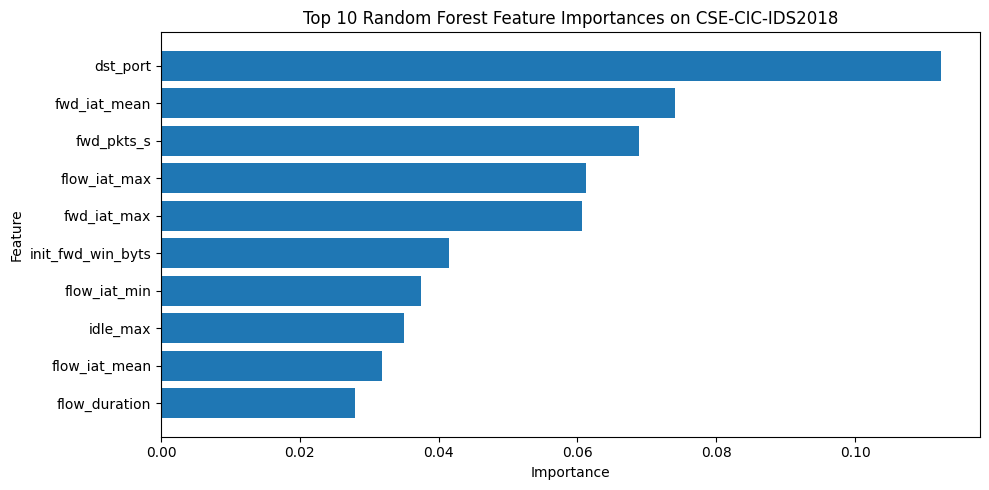

Saved feature importance graph and CSV.


,Feature,Importance
0,dst_port,0.112385
22,fwd_iat_mean,0.074052
37,fwd_pkts_s,0.068813
19,flow_iat_max,0.061224
24,fwd_iat_max,0.060624
66,init_fwd_win_byts,0.041514
20,flow_iat_min,0.037515
76,idle_max,0.035075
17,flow_iat_mean,0.031768
2,flow_duration,0.028012


Saved example IDS alert files.


,Field,Value
0,Model,Random Forest
1,Prediction,Attack
2,Attack probability,0.9986
3,True label in dataset,Attack
4,Analyst interpretation,The model flagged this flow as suspicious. The...


,Feature,Sample_Value
0,dst_port,8.000000e+01
1,fwd_iat_mean,3.662722e+05
2,fwd_pkts_s,2.747937e+00
3,flow_iat_max,1.865436e+06
4,fwd_iat_max,1.865436e+06


In [4]:
%run data_loader.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

Path("../results").mkdir(exist_ok=True)

# -----------------------------
# 1. Load CSE-CIC-IDS2018 sample
# -----------------------------
df_2018 = load_cicids2018(max_rows_per_file=2000)

print("2018 shape:", df_2018.shape)
print(df_2018["Label_Binary"].value_counts())

# -----------------------------
# 2. Prepare binary ML data
# -----------------------------
def clean_col_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )

def make_binary_target(series):
    numeric_s = pd.to_numeric(series, errors="coerce")
    non_null_numeric = numeric_s.dropna()

    if len(non_null_numeric) > 0:
        unique_vals = set(non_null_numeric.unique())
        if unique_vals.issubset({0, 1}):
            return numeric_s.astype(int)

    return series.apply(
        lambda x: 0 if str(x).strip().lower() in ["benign", "normal", "0"] else 1
    )

def prep_binary_df(df):
    temp = df.copy()
    temp.columns = [clean_col_name(c) for c in temp.columns]
    temp = temp.replace([np.inf, -np.inf], np.nan)

    if "label_binary" in temp.columns:
        y = make_binary_target(temp["label_binary"])
    elif "label" in temp.columns:
        y = make_binary_target(temp["label"])
    else:
        raise ValueError("No label column found")

    drop_cols = ["label", "label_binary", "sourcefile", "timestamp"]
    feature_cols = [c for c in temp.columns if c not in drop_cols]

    X = temp[feature_cols].copy()

    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X = X.dropna(axis=1, how="all")

    valid_rows = y.notna()
    X = X.loc[valid_rows]
    y = y.loc[valid_rows].astype(int)

    return X, y

X18, y18 = prep_binary_df(df_2018)

# Final safety cleanup before model training
X18 = X18.replace([np.inf, -np.inf], np.nan)
X18 = X18.mask(np.abs(X18) > 1e308, np.nan)
X18 = X18.dropna(axis=1, how="all")

print("X18 shape:", X18.shape)
print("y18 counts:")
print(y18.value_counts())

# -----------------------------
# 3. Train Random Forest
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X18,
    y18,
    test_size=0.25,
    random_state=42,
    stratify=y18
)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=25,
        max_depth=8,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

# -----------------------------
# 4. Feature importance graph
# -----------------------------
rf_model = rf_pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X18.columns,
    "Importance": rf_model.feature_importances_
})

top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances on CSE-CIC-IDS2018")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("../results/random_forest_feature_importance_2018.png", dpi=300, bbox_inches="tight")
plt.show()

top_features.to_csv("../results/random_forest_feature_importance_2018.csv", index=False)

print("Saved feature importance graph and CSV.")
display(top_features)

# -----------------------------
# 5. Example IDS alert interpretation
# -----------------------------
preds = rf_pipeline.predict(X_test)

class_list = list(rf_model.classes_)
if 1 in class_list:
    attack_col = class_list.index(1)
    probs = rf_pipeline.predict_proba(X_test)[:, attack_col]
else:
    probs = np.zeros(len(X_test))

alert_candidates = pd.DataFrame({
    "True_Label": y_test.values,
    "Predicted_Label": preds,
    "Attack_Probability": probs
}, index=X_test.index)

attack_matches = alert_candidates[
    (alert_candidates["True_Label"] == 1) &
    (alert_candidates["Predicted_Label"] == 1)
]

chosen_idx = attack_matches.sort_values(
    "Attack_Probability",
    ascending=False
).index[0]

chosen_row = X_test.loc[chosen_idx]
chosen_prob = alert_candidates.loc[chosen_idx, "Attack_Probability"]

top_feature_names = top_features["Feature"].head(5).tolist()

feature_values = pd.DataFrame({
    "Feature": top_feature_names,
    "Sample_Value": [chosen_row[f] for f in top_feature_names]
})

alert_summary = pd.DataFrame({
    "Field": [
        "Model",
        "Prediction",
        "Attack probability",
        "True label in dataset",
        "Analyst interpretation"
    ],
    "Value": [
        "Random Forest",
        "Attack",
        round(chosen_prob, 4),
        "Attack",
        "The model flagged this flow as suspicious. The feature values below come from the most important Random Forest features and would be reviewed by an analyst before treating the alert as confirmed."
    ]
})

alert_summary.to_csv("../results/example_ids_alert_summary.csv", index=False)
feature_values.to_csv("../results/example_ids_alert_feature_values.csv", index=False)

print("Saved example IDS alert files.")
display(alert_summary)
display(feature_values)

\subsection{Feature importance and alert interpretation}

To make the Random Forest model more interpretable, we also inspected feature importance scores from the CSE-CIC-IDS2018 experiment. This helped identify which network-flow features contributed most to the model's decisions. The purpose was not to fully explain every individual prediction, but to avoid treating the model as a complete black box.

We also created a small example IDS alert interpretation from one Random Forest prediction. The alert included the predicted class, the model's attack probability, and several high-importance feature values that an analyst could review. This makes the project more realistic because intrusion detection systems are not useful only because they produce a label; they also need to give analysts enough context to decide whether an alert deserves further investigation.